In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import ecc_vr 
importlib.reload(ecc_vr)
importlib.reload(ecc_vr.metrics)
import ecc_vr as vr

from pathlib import Path
import sys

week5_path = Path.cwd().parent / "Week5"
if str(week5_path) not in sys.path:
    sys.path.append(str(week5_path))

from Sphere_Ellipsoid_Utils import (
    unif_hypersphere,
    unif_hyperellipsoid,
    unit_ball_volume,
    scale_axes_target_volume,
    simulate_edge_curves_kde,
    plot_sphere_ellipsoid_results,
    simulate_triangle_curves_kde,
    non_unif_hyperellipsoid,
)


from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

In [4]:
def sphere_vs_ellipsoid_concat_curve_classifier_kde(
        n_points: int = 100,
        t_grid: np.ndarray | None = None,
        n_resamples: int = 300,
        ambient_dim: int | None = None,
        ellipsoid_stretch: np.ndarray | list | tuple | None = None,
        h: float = 0.15,
        target_volume: float = 1.0,
        seed1: int = 42,
        seed2: int = 43,
        seed3: int = 44,
        seed4: int = 45,
        test_size: float = 0.25,
        random_state: int = 0,
):  
    
    if t_grid is None:
        t_grid = np.linspace(0.5, 5, 30)
    else:
        t_grid = np.asarray(t_grid, dtype = float)

    if ellipsoid_stretch is None:
        ambient_dim = 3 if ambient_dim is None else ambient_dim
        ellipsoid_stretch = np.ones(ambient_dim, dtype = float)
        ellipsoid_stretch[0] = 1.5
    else:
        ellipsoid_stretch = np.asarray(ellipsoid_stretch, dtype = float)
        if ambient_dim is None:
            ambient_dim = ellipsoid_stretch.size
            raise ValueError("ambient_dim must match len(ellipsoid_stretch).")
    
    target_volume = unit_ball_volume(ambient_dim) * np.prod(ellipsoid_stretch)
    
    sphere_radius = (target_volume / unit_ball_volume(ambient_dim)) ** ( 1.0 / ambient_dim)
    ellipsoid_axes = scale_axes_target_volume(ellipsoid_stretch, target_volume)

    edge_curves_sphere = simulate_edge_curves_kde(
        point_cloud_sampler = lambda s: unif_hypersphere(
            n_points = n_points,
            d = ambient_dim,
            r = sphere_radius,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        h = h,
        seed = seed1,
    )

    triangle_curves_sphere = simulate_triangle_curves_kde(
        point_cloud_sampler = lambda s: unif_hypersphere(
            n_points = n_points,
            d = ambient_dim,
            r = sphere_radius,
            seed = s,
        ),
        n_resamples = n_resamples,
        t_grid = t_grid,
        h = h,
        seed = seed3
    )
    
    edge_curves_ellipsoid = simulate_edge_curves_kde(
        point_cloud_sampler=lambda s: non_unif_hyperellipsoid(
            n_points,
            *ellipsoid_axes,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        h = h,
        seed=seed2,
    )

    triangle_curves_ellipsoid = simulate_triangle_curves_kde(
        point_cloud_sampler=lambda s: non_unif_hyperellipsoid(
            n_points,
            *ellipsoid_axes,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        h = h,
        seed=seed4,
    )

    curves_sphere = np.hstack([edge_curves_sphere, triangle_curves_sphere])
    curves_ellipsoid = np.hstack([edge_curves_ellipsoid, triangle_curves_ellipsoid])

    X = np.vstack([curves_sphere, curves_ellipsoid])
    y = np.array([0] * len(curves_sphere) + [1] * len(curves_ellipsoid))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = test_size,
        random_state=random_state,
        stratify=y
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter = 5000),
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        "shape1": "sphere",
        "shape2": "ellipsoid",
        "ambient_dim": ambient_dim,
        "target_volume": target_volume,
        "sphere_radius": sphere_radius,
        "ellipsoid_stretch_input": np.asarray(ellipsoid_stretch, dtype = float),
        "ellipsoid_axes": ellipsoid_axes,
        "t_grid": t_grid,
        "curves1": curves_sphere,
        "curves2": curves_ellipsoid,
        "curves_sphere": curves_sphere,
        "curves_ellipsoid": curves_ellipsoid,
        "classifier": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(
            y_test,
            y_pred,
            target_names=["Sphere", "Ellipsoid"],
            zero_division=0,
        ),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
    }

def plot_sphere_ellipsoid_concat_results(result):
    t_grid = result["t_grid"]
    m = len(t_grid)

    curves_sphere = result["curves_sphere"]
    curves_ellipsoid = result["curves_ellipsoid"]

    sphere_edge = curves_sphere[:, :m]
    sphere_triangle = curves_sphere[:, m:]

    ellipsoid_edge = curves_ellipsoid[:, :m]
    ellipsoid_triangle = curves_ellipsoid[:, m:]

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    mean_se = sphere_edge.mean(axis=0)
    sd_se = sphere_edge.std(axis=0, ddof=1)
    mean_ee = ellipsoid_edge.mean(axis=0)
    sd_ee = ellipsoid_edge.std(axis=0, ddof=1)

    ax[0].plot(t_grid, mean_se, lw=2, label="Sphere Edge Mean")
    ax[0].fill_between(t_grid, mean_se - sd_se, mean_se + sd_se, alpha=0.2)
    ax[0].plot(t_grid, mean_ee, lw=2, label="Ellipsoid Edge Mean")
    ax[0].fill_between(t_grid, mean_ee - sd_ee, mean_ee + sd_ee, alpha=0.2)
    ax[0].set_title("Edge Curves")
    ax[0].set_xlabel("t")
    ax[0].set_ylabel("Count")
    ax[0].legend()

    mean_st = sphere_triangle.mean(axis=0)
    sd_st = sphere_triangle.std(axis=0, ddof=1)
    mean_et = ellipsoid_triangle.mean(axis=0)
    sd_et = ellipsoid_triangle.std(axis=0, ddof=1)

    ax[1].plot(t_grid, mean_st, lw=2, label="Sphere Triangle Mean")
    ax[1].fill_between(t_grid, mean_st - sd_st, mean_st + sd_st, alpha=0.2)
    ax[1].plot(t_grid, mean_et, lw=2, label="Ellipsoid Triangle Mean")
    ax[1].fill_between(t_grid, mean_et - sd_et, mean_et + sd_et, alpha=0.2)
    ax[1].set_title("Triangle Curves")
    ax[1].set_xlabel("t")
    ax[1].set_ylabel("Count")
    ax[1].legend()

    ConfusionMatrixDisplay.from_predictions(
        result["y_test"],
        result["y_pred"],
        display_labels=["Sphere", "Ellipsoid"],
        cmap="Blues",
        ax=ax[2],
    )
    ax[2].set_title("Classifier Confusion Matrix")

    plt.tight_layout()
    plt.show()

    print("Accuracy:", result["accuracy"])
    print(result)


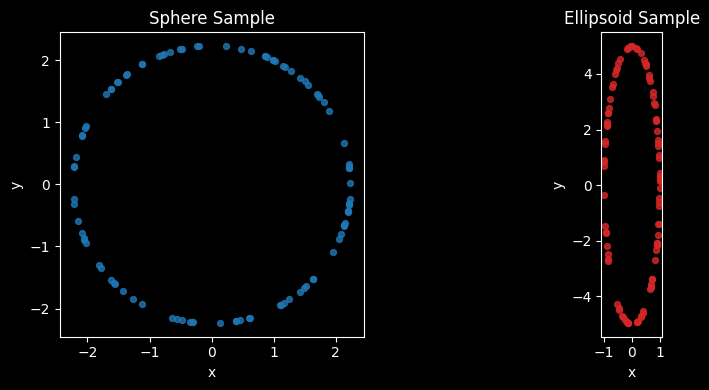

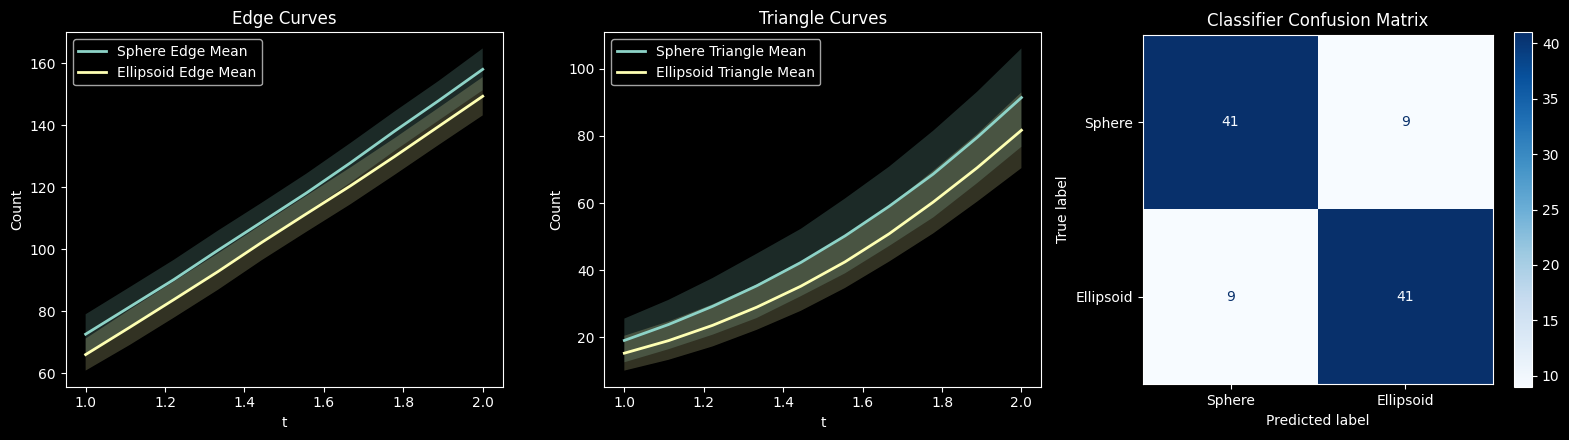

Accuracy: 0.82
{'shape1': 'sphere', 'shape2': 'ellipsoid', 'ambient_dim': 2, 'target_volume': np.float64(15.707963267948966), 'sphere_radius': np.float64(2.23606797749979), 'ellipsoid_stretch_input': array([1., 5.]), 'ellipsoid_axes': array([1., 5.]), 't_grid': array([1.        , 1.11111111, 1.22222222, 1.33333333, 1.44444444,
       1.55555556, 1.66666667, 1.77777778, 1.88888889, 2.        ]), 'curves1': array([[ 79.,  85.,  91., ...,  58.,  69.,  89.],
       [ 82.,  93.,  98., ...,  56.,  73.,  82.],
       [ 77.,  86.,  91., ...,  68.,  85., 102.],
       ...,
       [ 74.,  84.,  90., ...,  59.,  83.,  99.],
       [ 74.,  82.,  92., ...,  62.,  79.,  93.],
       [ 68.,  80.,  93., ...,  85.,  95., 103.]], shape=(200, 20)), 'curves2': array([[64., 72., 77., ..., 57., 62., 74.],
       [72., 80., 93., ..., 73., 83., 95.],
       [63., 72., 79., ..., 65., 76., 97.],
       ...,
       [63., 76., 83., ..., 69., 78., 95.],
       [60., 67., 74., ..., 59., 71., 78.],
       [61., 75.,

In [5]:
plt.style.use("dark_background")

# INPUT
n_points = 100
n_resamples = 200
ambient_dim = 2
h = 0.2
t_grid = np.linspace(1,2,10)

ellipsoid_stretch = [1.0, 5.0]

result = sphere_vs_ellipsoid_concat_curve_classifier_kde(
    ambient_dim=ambient_dim,
    n_points=n_points,
    n_resamples=n_resamples,
    t_grid=t_grid,
    h = h,
    ellipsoid_stretch=ellipsoid_stretch,
)

fig = plt.figure(figsize=(10, 4))

samples = [
    ("Sphere", unif_hypersphere(n_points, result["ambient_dim"], r = result["sphere_radius"], seed = 123), "tab:blue"),
    ("Ellipsoid", non_unif_hyperellipsoid(n_points, result["ellipsoid_axes"], seed = 456), "tab:red"),
]

for i, (shape, X, color) in enumerate(samples, start = 1):
    projected = X.shape[1] > 3
    if projected:
        X = vr.pca_project(X, out_dim = 2)
    
    d = X.shape[1]
    ax = fig.add_subplot(1, 2, i, projection="3d" if d == 3 else None)

    if d == 3:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], s = 18, alpha = 0.8, color=color)
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
    elif d == 2:
        ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.8, color=color)
        ax.set_aspect("equal")
        ax.set_xlabel("PC1" if projected else "x")
        ax.set_ylabel("PC2" if projected else "y")
    else:
        ax.scatter(X[:, 0], np.zeros(len(X)), s=18, alpha=0.8, color=color)
        ax.set_xlabel("x")
        ax.set_ylabel("")

    ax.set_title(f"{shape} Sample")
    ax.grid(False)

plt.tight_layout()
plt.show()

plot_sphere_ellipsoid_concat_results(result)
